The code below illustrates an example for plotting OH reactivity for different species from paired NetCDF files generated by Melodies-Monet. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import to_hex
import xarray as xr

In [2]:
# Plotting parameters I like, but don't need to include if there's a uniform melodies-monet scheme
plt.rcParams['font.size'] = 16  # Set to your desired font size
plt.rcParams['font.weight'] = 'bold' 
plt.rcParams['axes.titleweight'] = 'bold'  # For the main plot title
plt.rcParams['axes.labelweight'] = 'bold'  # For x and y axes labels

Setting some physical constants:

In [3]:
k_B = 1.380649e-23 # Boltzmann constant J/K

Define a function to calculate the Arrhenius equation

In [4]:
def ARR2(A0,B0,Temp): # Temp in Kelvin
    ARR2 = A0*np.exp(-B0/Temp)
    return ARR2

Add your paths to paired netcdf files for plotting here. Group them all into a dictionary as seen in the bottom of the following cell.

In [5]:
# Example netcdf paths for RECAP-CA flights
path_03 = '/scratch3/BMC/rcm2/syoun/RECAP_WRFChem/BEIS/No_T2_Correction/0603_RECAP_recap_wrfchem_v4.2.nc4'
path_08 = '/scratch3/BMC/rcm2/syoun/RECAP_WRFChem/BEIS/No_T2_Correction/0608_RECAP_recap_wrfchem_v4.2.nc4'
path_09 = '/scratch3/BMC/rcm2/syoun/RECAP_WRFChem/BEIS/No_T2_Correction/0609_RECAP_recap_wrfchem_v4.2.nc4'
path_13 = '/scratch3/BMC/rcm2/syoun/RECAP_WRFChem/BEIS/No_T2_Correction/0613_RECAP_recap_wrfchem_v4.2.nc4'
path_15 = '/scratch3/BMC/rcm2/syoun/RECAP_WRFChem/BEIS/No_T2_Correction/0615_RECAP_recap_wrfchem_v4.2.nc4'
path_16 = '/scratch3/BMC/rcm2/syoun/RECAP_WRFChem/BEIS/No_T2_Correction/0616_RECAP_recap_wrfchem_v4.2.nc4'
path_22 = '/scratch3/BMC/rcm2/syoun/RECAP_WRFChem/BEIS/No_T2_Correction/0622_RECAP_recap_wrfchem_v4.2.nc4'

# Dictionary of all paths
dict_paths = {'recap_03': path_03, 'recap_08': path_08, 'recap_09': path_09, 'recap_13': path_13, 'recap_15': path_15, 'recap_16': path_16, 'recap_22': path_22}

Set dates of different flights to be used for plotting labels

In [6]:
dates = ["2021-06-03","2021-06-08","2021-06-09",
           "2021-06-13","2021-06-15","2021-06-16","2021-06-22"]

Loop through the netcdfs and add them as dataframes to a new dictionary

In [7]:
dict_dfs = {}

for key, path in dict_paths.items():
    # Using 'with' ensures the file is closed properly after reading
    with xr.open_dataset(path) as ds:
        dict_dfs[key] = ds.to_dataframe().reset_index()

Make sure your temperature and pressure are in the correct units (Kelvin and mbar respectively). If not, modify them here:

In [8]:
# Convert temperature from Celsius to Kelvin if needed (needed for RECAP, not needed for Kelvin)
for key, df in dict_dfs.items():
    df['temperature_obs'] = df['temperature_obs'] + 273.15

Below is a list of dictionaries for species-specific values needed for calculating OH reactivity (sourced from: https://github.com/NOAA-CSL/WRF-Chem_CSL_Publications/blob/1f8b97253dd587697cbbdf8e75b6ddc6ede5745d/Qindan_Zhu_et_al_2024/WRF-Chem-source-code/RACM2B-VCP/WRF-Chem-csl_release-v4.2.2_racm_berk_vcp_noI/chem/KPP/mechanisms/r2smh/r2smh.eqn). Mainly sourcing the A0 and B0 values. Add/modify species as appropriate for your analysis.

The structure of the dictionary is as follows: \
key: species wrf name: (1) observation name, (2) compound common name, (3) calibrated flag (1 = calibrated, 0 = uncalibrated) - depends on instrumentation in your particular campaign of interest, (4) ARR2 flag (1 = use ARR2 function, 0 = do not, 2 = some other routine to be handled later in the main calculation code), (5) if ARR2 flag = 1: A0; ARR2 flag = 0: kOH, (6) B0 

In [9]:
spc_dict = {'moh':  ['x33_0334892273_CH5O_', 'Methanol', 1, 1, 2.85e-12, 345], # {106:073} MOH+HO=HO2+HCHO+OHR+OHVOC : ARR2( 2.85D-12 , 345.0_dp , TEMP ) ;
        'eoh':   ['x47_0491409302_C2H7O_', 'Ethanol', 1, 1, 3.00e-12, -20], # {107:074} EOH+HO=HO2+ACD+OHR+OHVOC : ARR2( 3.00D-12 , -20.0_dp , TEMP ) ;
        'iso':   ['x69_0698776245_C5H9_', 'Isoprene', 1, 1, 3.1e-11, -350], #  {083:050} ISO+HO=ISOP+OHR+OHVOC+OHBVOC  : ARR2( 3.1D-11 , -350.0_dp, TEMP) ;
        'act':   ['x59_0491409302_C3H7O_', 'Acetone + Propanal', 1, 2], #  {089:056} ACT+HO=ACTP+H2O+OHR+OHVOC : (8.8D-12 * EXP(-1320.0_dp/TEMP) + 1.7D-14 * EXP(423.0_dp/TEMP) ) ;
        'monoterpenes_tot':   ['x137_1324768066_C10H17_','Monoterpenes', 1, 2], #  {084:051} API+HO=APIP+OHR+OHVOC+OHBVOC : ARR2( 1.21D-11 , -440.0_dp, TEMP ) ; {085:052} LIM+HO=LIMP+OHR+OHVOC+OHBVOC : ARR2( 4.20D-11 , -401.0_dp , TEMP ); {560:523} ECLP+HO=0.951 HC8P+0.025 ALD+0.024 HKET+0.049 HO2+H2O+OHR+OHVOC : 1.11D-11;
        'sesq':   ['x205_1950836182_C15H25_','Sesquiterpenes', 1, 0, 2.52e-10], # {526:493} SESQ+HO=0.36 KET+0.3 HCHO+0.05 ORA1+0.19 OLIP                        : 2.52D-10 ;
        'tol':   ['x93_0698776245_C7H9_','Toluene', 1, 1, 1.81e-12, -354], # {080:047} TOL+HO=0.060 TLP1+0.763 TR2+0.177 CSL+0.177 HO2+OHR+OHVOC : ARR2( 1.81D-12 , -354.0_dp, TEMP ) ;
        'acd':   ['x45_0334892273_C2H5O_','Acetaldehyde', 1, 1, 4.38e-12, -366.0], # {087:054} ACD+HO=ACO3+H2O+OHR+OHVOC  : ARR2( 4.38D-12 , -366.0_dp , TEMP ) ;
        'mek':   ['x73_0647888184_C4H9O_','Methyl Ethyl Ketone', 1, 1, 1.30e-12, 25], # {090:057} MEK+HO=MEKP+H2O+OHR+OHVOC : ARR2( 1.30D-12 , 25.0_dp , TEMP ) ;
        'ben':   ['x79_0542297363_C6H7_','Benzene', 1, 1, 2.33e-12, 193.0], # {079:046} BEN+HO=0.352 BENP+0.118 EPX+0.530 PHEN+0.648 HO2+OHR+OHVOC :ARR2( 2.33D-12 , 193.0_dp , TEMP) ;
        'bald':  ['x107_0491409302_C7H7O_','Benzaldehyde', 1, 1, 5.32e-12, -243], # {101:068} BALD+HO=BALP+H2O+OHR+OHVOC : ARR2( 5.32D-12 , -243.0_dp , TEMP ) ;
        'xylene_tot':   ['xylene_tot_obs','Xylene + Trimethylbenzene', 1, 2], #  {081:048} XYL+HO=0.060 XYL1+0.763 XY2+0.177 CSL+0.177 HO2+OHR+OHVOC : 2.13D-11 ; {082:049} XYO+HO=0.060 XYL1+0.890 XYO2+0.050 CSL+0.050 HO2+OHR+OHVOC : 1.37D-11 ; 
        'csl':   ['x109_0647888184_C7H9O_','p-Cresol', 1, 0, 4.65e-11], # {103:070} CSL+HO=0.07 CHO+0.20 ADDC+0.73 MCT+0.73 HO2+OHR+OHVOC : 4.65D-11 ; 
        'nald':   ['x143_1430358887_C9H19O_','Nonanal', 1, 1, 8.08e-12 , -410.0], # {546:513} NALD+HO=0.15 HC8P+0.85 RCO3+H2O+OHR+OHVOC : ARR2( 8.08D-12 , -410.0_dp, TEMP ) ;
        'macr_mvk_isopooh_tot':   ['x71_0491409302_C4H7O_','MACR + MVK + ISOP OXD', 1, 2], # {093:060} MACR+HO=0.53 MACP+0.47 MACRO2+OHR+OHVOC+OHBVOC : ARR2(8.0D-12 , -380.0_dp , TEMP ); {094:061} MVK+HO=MVKP+OHR+OHVOC+OHBVOC : ARR2( 2.60D-12 , -610.0_dp , TEMP ) ; 
        'd4silx':   ['x297_0824279785_C8H25O4Si4_','D4 Siloxane', 1, 0, 1.3e-12], # {532:499} D4SILX+HO=ROH+OHR+OHVOC :1.3D-12;
        'd5silx':   ['x371_1012268066_C10H31O5Si5_','D5 Siloxane', 1, 0, 2.1e-12], # {533:500} D5SILX+HO=ROH+OHR+OHVOC :2.1D-12;  
        ############# Uncalibrated from this point
        'pcbtf':   ['x181_0026397705_C7H4ClF3H_','PCBTF', 0, 0, 2.5e-13], # {534:501} PCBTF+HO=0.060 TLP1+0.763 TR2+0.177 CSL+0.177 HO2+OHR+OHVOC      : 2.5D-13 ;
        'pdcbz':   ['x146_9762878418_C6Cl2H5_','PDCBZ', 0, 0, 3.2e-13], # {535:502} PDCBZ+HO=0.352 BENP+0.118 EPX+0.530 PHEN+0.648 HO2+OHR+OHVOC     : 3.2D-13 ; 
        'oald':   ['x129_1273956299_C8H17O_','Octanal', 0, 1, 7.78e-12, -410.0], # {548:515} OALD+HO=0.14 HC8P+0.86 RCO3+H2O+OHR+OHVOC : ARR2( 7.78D-12 , -410.0_dp, TEMP ) ;
        'ora2':   ['x61_0284042358_C2H5O2_','Acetic Acid', 0, 1, 2.20e-14, -1012.0], # {115:082} ORA2+HO=0.64 MO2+0.64 CO2+0.36 ORAP+OHR  : ARR2( 2.20D-14 , -1012.0_dp , TEMP ) ;
        'phen':   ['x95_0491409302_C6H7O_','Phenol', 0, 1, 6.75e-12, -405.0], # {102:069} PHEN+HO=0.07 CHO+0.20 ADDC+0.73 MCT+0.73 HO2+OHR+OHVOC : ARR2( 6.75D-12 , -405.0_dp , TEMP ) ;
        'pyac':   ['x89_0233230591_C3H5O3_','Pyruvic Acid', 0, 0, 8.0e-13], # {399:366} PYAC+HO=ACO3+CO2+OHR : 8.0D-13 ;
        'glycr':   ['x93_0546188354_C3H9O3_','Glycerol', 0, 0, 5.45e-11] # {524:491} GLYCR+HO=0.45 ALD+0.55 HKET+HO2 : 5.45D-11 ;
}

# Pfannerstill et al 2023 Table S1: (30% a-pinene, 14% d3-carene, 36% sabinene, 4% camphene, 2% b-pinene, and 14% limonene)
# xyl + xyo (Take xyl 2/3 and xyo 1/3 for weighted kOH) - from conversation with Quazi and Becky
# (macr+mvk) : 50:50 % weighted kOH - from conversation with Quazi and Becky

Calculating the kOH:

In [10]:
# Calculate the rate of reaction (k_OH) for each VOC at each temperature
# df_03['k_OH_obs'] = df_03.apply(lambda row: ARR2(A0,B0,row['temperature_obs']), axis=1)

# # Convert VOC mixing ratio (ppbv) to number concentration (mol cm^-3)
# df_03['N_tot_obs'] = (df_03['pressure_obs']/(k_B * df_03['temperature_obs']))/(1e6)
# df_03['voc_num'] = df_03['x33_0334892273_CH5O_'] * df_03['N_tot_obs'] * 1e-9
# df_03['VOC_r'] = df_03['k_OH_obs'] * df_03['voc_num']

lst_new_dfs = []

for key, df in dict_dfs.items():
    df_new = pd.DataFrame()
    for key in spc_dict.keys():
        obs_spc = str(spc_dict[key][0])
        mod_spc = str(key)
        # print(obs_spc)
        # Check that VOC is calibrated
        if spc_dict[key][2] == 1:
            # Calculate KOH
            if spc_dict[key][3] == 1:
                df['KOH_' + obs_spc] = df.apply(lambda row: ARR2(spc_dict[key][4],spc_dict[key][5],row['temperature_obs']), axis=1)
            elif spc_dict[key][3] == 0:
                df['KOH_' + obs_spc] = spc_dict[key][4]
            elif spc_dict[key][3] == 2:
                if key == 'act':
                    df['KOH_' + obs_spc] = df.apply(lambda row: 8.8e-12 * np.exp(-1320.0/row['temperature_obs']) + 1.7e-14 * np.exp(423.0/row['temperature_obs']), axis=1)
                if key == 'monoterpenes_tot':
                    df['KOH_' + obs_spc] = df.apply(lambda row: (0.3*ARR2(1.21e-11,-440.0,row['temperature_obs'])) + (0.14*ARR2(4.20e-11,-401.0,row['temperature_obs'])), axis=1)
                if key == 'xylene_tot':
                    df['KOH_' + obs_spc] = ((2/3)*2.13e-11) + ((1/3)*1.37e-11)
                    mod_spc = 'xylene_tot_wrf'
                if key == 'macr_mvk_isopooh_tot':
                    df['KOH_' + obs_spc] = df.apply(lambda row: (0.5*ARR2(8.0e-12,-380.0,row['temperature_obs'])) + (0.5*ARR2(2.60e-12,-610.0,row['temperature_obs'])), axis=1)                  
            # N_tot calculation - only use either obs pressure/temp to calculate since we only want to compare VOC concentrations (and not how well wrf/obs pressure and temp are aligned), also compare to value of 2e19 Qindan used using STP values
            df[obs_spc + '_N_tot'] = (df['pressure_obs'] / (k_B*df['temperature_obs']))/(1e6)
            # RECAP Observation voc_num
            df[obs_spc + '_voc_num'] = df[obs_spc] * df[obs_spc + '_N_tot'] * (1e-9)
            # WRF Model voc_num
            df[mod_spc + '_voc_num'] = df[mod_spc] * df[obs_spc + '_N_tot'] * (1e-9)
            # RECAP Observation voc_r
            df_new[obs_spc + '_voc_r'] = df['KOH_' + obs_spc] * df[obs_spc + '_voc_num']
            # WRF Model voc_r
            df_new[mod_spc + '_voc_r'] = df['KOH_' + obs_spc] * df[mod_spc + '_voc_num']
    lst_new_dfs.append(df_new)

For calculating uncertainty metrics and preparing data to plot, list the relevant OH reactivity fields generated from the code above for the species you are interested in plotting:

In [11]:
lst_obs_voc_r = ['x33_0334892273_CH5O__voc_r', 'x47_0491409302_C2H7O__voc_r', 'x69_0698776245_C5H9__voc_r', 'x59_0491409302_C3H7O__voc_r', 'x137_1324768066_C10H17__voc_r', 'x205_1950836182_C15H25__voc_r', 'x93_0698776245_C7H9__voc_r', 'x45_0334892273_C2H5O__voc_r', 'x73_0647888184_C4H9O__voc_r', 
               'x79_0542297363_C6H7__voc_r', 'x107_0491409302_C7H7O__voc_r', 'xylene_tot_obs_voc_r', 'x109_0647888184_C7H9O__voc_r', 'x143_1430358887_C9H19O__voc_r', 'x71_0491409302_C4H7O__voc_r', 'x297_0824279785_C8H25O4Si4__voc_r', 'x371_1012268066_C10H31O5Si5__voc_r']

Calculate uncertainty metrics for each dataset and prepare data for plotting:

In [12]:
lst_labels = []
for key in spc_dict.keys():
    if spc_dict[key][2] == 1:
        lst_labels.append(spc_dict[key][1])

lst_plotting_df = []
lst_errorbar_obs = []
lst_errorbar_model = []

for i,df in enumerate(lst_new_dfs):  
    df_obs_voc_r = df[lst_obs_voc_r]
    df_model_voc_r = df.loc[:, ~df.columns.isin(lst_obs_voc_r)]
    
    first_non_nan_index = df_obs_voc_r.first_valid_index()
    df_model_voc_r = df_model_voc_r.iloc[first_non_nan_index:]

    # CALCULATE IQR AND/OR STD HERE
    row_sums = df_obs_voc_r.sum(axis=1)
    Q3 = row_sums[row_sums != 0].quantile(0.75)
    Q1 = row_sums[row_sums != 0].quantile(0.25)
    IQR = Q3-Q1
    lst_errorbar_obs.append(IQR)

    row_sums = df_model_voc_r.sum(axis=1)
    Q3 = row_sums[row_sums != 0].quantile(0.75)
    Q1 = row_sums[row_sums != 0].quantile(0.25)
    IQR = Q3-Q1
    lst_errorbar_model.append(IQR)
    
    # Calculate column-wise median
    medians_obs = df_obs_voc_r.median()
    medians_model = df_model_voc_r.median()
  
    median_values = list(zip(medians_obs,medians_model))
    # print(median_values)
    plotting_dict = dict(zip(lst_labels,median_values))
    # print(plotting_dict)
    
    df_plotting = pd.DataFrame(plotting_dict, index=['RECAP Obs', 'WRF-Chem'])
    lst_plotting_df.append(df_plotting)

Plotting script:

/tmp/ipykernel_1649529/3305120458.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))
/tmp/ipykernel_1649529/3305120458.py:61: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


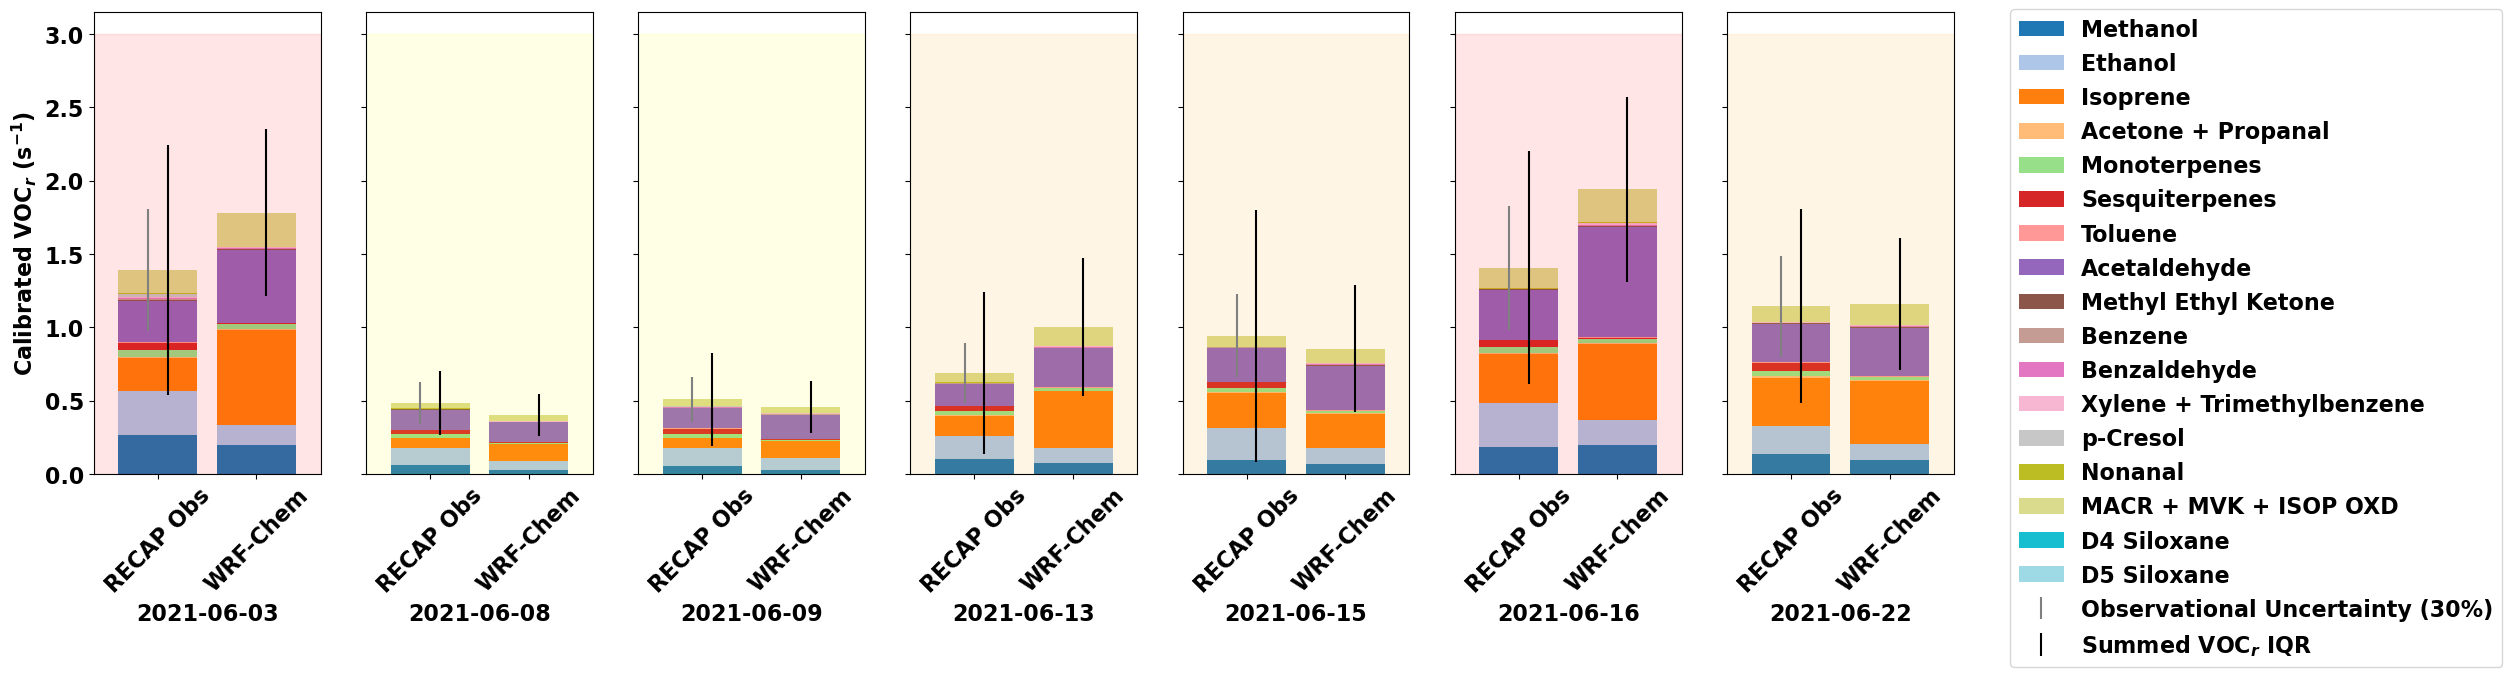

In [13]:
total_plots = len(lst_plotting_df)

# Get consistent list of categories across all DataFrames
all_categories = [value[1] for value in spc_dict.values() if value[2] == 1]

# Generate consistent color map
cmap = cm.get_cmap('tab20', len(all_categories))
color_dict = {cat: to_hex(cmap(i)) for i, cat in enumerate(all_categories)}

fig, axes = plt.subplots(1, total_plots, figsize=(24, 6), sharey=True)

for i, ax in enumerate(axes):
    df = lst_plotting_df[i]

    # Reorder df to match the consistent color order
    df = df[[col for col in all_categories if col in df.columns]]

    # Plot with consistent colors
    df.plot(kind='bar', stacked=True, color=[color_dict[col] for col in df.columns], 
            width=0.8, ax=ax)

    bar_tops = df[df > 0].sum(axis=1).values
    x_pos = range(len(df))  
    x_left_shift = [x - 0.1 for x in x_pos]
    x_right_shift = [x + 0.1 for x in x_pos]
    errors = [lst_errorbar_obs[i], lst_errorbar_model[i]]

    # Observational error
    ax.errorbar(x=x_left_shift, y=bar_tops, yerr=[bar_tops[0]*0.3, 0], fmt='none',
                ecolor='gray', capsize=0, label='Observational Uncertainty (30%)')
    
    # Model error
    ax.errorbar(x=x_right_shift, y=bar_tops, yerr=errors, fmt='none',
                ecolor='black', capsize=0, linestyle='dotted', label='Summed VOC$_r$ IQR')

    # Background shading
    ylim = 3

    # Optional code to shade the background of each subplot a different color if, for example, you want to differentiate between e.g. relatively cool, warm, and hot days
    if dates[i] in ["2021-06-03", "2021-06-16"]:
        ax.axhspan(0, ylim, color='red', alpha=0.1)
    elif dates[i] in ["2021-06-08", "2021-06-09"]:
        ax.axhspan(0, ylim, color='yellow', alpha=0.1)
    else:
        ax.axhspan(0, ylim, color='orange', alpha=0.1)

    ax.set_xlabel(dates[i])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)#, ha='right')

    ax.set_ylim(0)

    if i == 0:
        ax.set_ylabel('Calibrated VOC$_r$ (s$^{-1}$)')

    if i == 0:
        # ax.legend(bbox_to_anchor=(11.05, 1.03), loc='upper left')
        ax.legend(bbox_to_anchor=(8.4, 1.03), loc='upper left')
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()